# 04 — Activations, Initialization, and Gradient Flow (Manual NumPy)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Without a nonlinear activation, stacked dense layers collapse into a single affine transformation. ReLU creates piecewise-linear nonlinear behavior while avoiding the severe positive-side saturation of sigmoid/tanh. Initialization controls the distribution of pre-activations before training begins.

- **Xavier/Glorot** targets variance stability for approximately symmetric activations.
- **He/Kaiming** compensates for ReLU discarding roughly half of a symmetric signal.

Bad scale can saturate units, kill ReLUs or explode/vanish gradients.


## Code walkthrough — compare activation functions and their derivatives
The plots show both output and local derivative. Backpropagation multiplies upstream gradients by these derivatives, so a derivative near zero blocks learning even when the forward activation looks numerically valid.


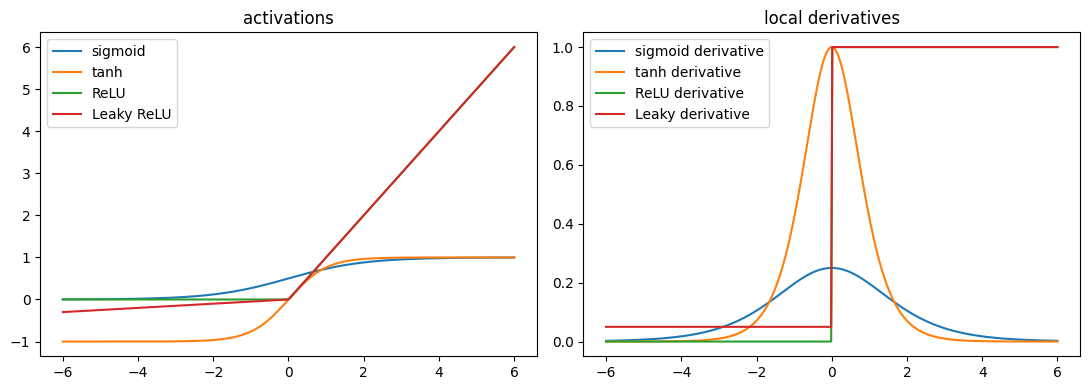

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 400)
sig = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(z, 0)
leaky = np.where(z > 0, z, 0.05 * z)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for arr, label in [
    (sig, "sigmoid"),
    (tanh, "tanh"),
    (relu, "ReLU"),
    (leaky, "Leaky ReLU"),
]:
    axes[0].plot(z, arr, label=label)
for arr, label in [
    (sig * (1 - sig), "sigmoid derivative"),
    (1 - tanh**2, "tanh derivative"),
    ((z > 0).astype(float), "ReLU derivative"),
    (np.where(z > 0, 1, 0.05), "Leaky derivative"),
]:
    axes[1].plot(z, arr, label=label)
axes[0].legend()
axes[1].legend()
axes[0].set_title("activations")
axes[1].set_title("local derivatives")
plt.tight_layout()
plt.show()

## Code walkthrough — initialization scale changes signal propagation
We propagate a random batch through several random ReLU layers using three scales. The variance and percentage of zero activations expose why initialization is part of optimization, not mere bookkeeping.


In [2]:
rng = np.random.default_rng(42)
X = rng.normal(size=(1000, 128))
for scale in [0.02, np.sqrt(2 / 128), 1.0]:
    A = X.copy()
    stats = []
    for depth in range(5):
        W = rng.normal(0, scale, size=(A.shape[1], 128))
        A = np.maximum(A @ W, 0)
        stats.append((A.std(), (A == 0).mean()))
    print(
        "scale",
        round(float(scale), 4),
        "layer std/dead%",
        [(round(s, 3), round(d, 3)) for s, d in stats],
    )

scale 0.02 layer std/dead% [(0.134, 0.5), (0.022, 0.487), (0.004, 0.425), (0.001, 0.52), (0.0, 0.498)]
scale 0.125 layer std/dead% [(0.828, 0.498), (0.85, 0.481), (0.825, 0.522), (0.829, 0.489), (0.805, 0.503)]
scale 1.0 layer std/dead% [(6.66, 0.5), (52.86, 0.513), (441.769, 0.48), (3539.591, 0.517), (28573.09, 0.491)]


## Production implication
Initialization problems usually appear as training instability, NaNs, non-improving loss or highly variable runs. In a governed ML pipeline, seeds, initialization policy and optimizer configuration belong in experiment metadata.


### Interactive Plotly lab — clone + run locally

## Interactive activation + derivative explorer

> **GitHub vs local behavior.** GitHub keeps the committed static plots, tables, metrics and explanations visible. **Clone this branch, create `environment.yml`, open the notebook in VS Code/Jupyter, select the Conda kernel, and run the cell below for full Plotly interactivity**: hover, zoom, pan, 3D rotation, legend selection, sliders and animation.

Use the dropdown to compare activation values and local derivatives. Backpropagation multiplies by this local slope, so near-zero regions make saturation and vanishing gradients directly inspectable.

**Production/business interpretation.** The interaction is an inspection instrument, not decoration: change or inspect a technical quantity and connect it to model behavior, operational risk or downstream decision quality.


In [3]:
import os
import numpy as np
import plotly.graph_objects as go

x = np.linspace(-6, 6, 500)
s = 1.0 / (1.0 + np.exp(-x))
functions = {"Sigmoid": (s, s * (1 - s)), "Tanh": (np.tanh(x), 1 - np.tanh(x) ** 2), "ReLU": (np.maximum(x, 0), (x > 0).astype(float)), "Leaky ReLU": (np.where(x > 0, x, 0.1 * x), np.where(x > 0, 1.0, 0.1))}
fig = go.Figure()
for name, (y, dy) in functions.items():
    visible = name == "Sigmoid"
    fig.add_trace(go.Scatter(x=x, y=y, mode="lines", name=f"{name} activation", visible=visible, hovertemplate="z=%{x:.2f}<br>a=%{y:.4f}<extra></extra>"))
    fig.add_trace(go.Scatter(x=x, y=dy, mode="lines", name=f"{name} derivative", line=dict(dash="dash"), visible=visible, hovertemplate="z=%{x:.2f}<br>da/dz=%{y:.4f}<extra></extra>"))
names = list(functions)
buttons = []
for idx, name in enumerate(names):
    visible = [False] * (2 * len(names)); visible[2 * idx] = visible[2 * idx + 1] = True
    buttons.append(dict(label=name, method="update", args=[dict(visible=visible), dict(title=f"{name}: activation and local gradient")]))
fig.update_layout(title="Sigmoid: activation and local gradient", xaxis_title="pre-activation z", yaxis_title="value", hovermode="x unified", updatemenus=[dict(buttons=buttons, x=1.02, y=1.0)])
if os.getenv("GITHUB_ACTIONS") == "true":
    print("Interactive activation explorer built. Run locally to inspect saturation and local gradients.")
else:
    fig.show(renderer="plotly_mimetype")


Interactive activation explorer built. Run locally to inspect saturation and local gradients.
